# CS4603 PA4 — Document Analyst

Development & testing notebook. Section headers match the tasks in `README.md`.
Fill in each cell, run everything top-to-bottom, and **keep all outputs visible** before submitting.
Record explanations and analysis answers in `STUDENT_ANALYSIS.md`.


## Part 0 — Setup & Corpus Ingestion
Env config + ingest `data/annual_report.pdf` into Databricks Vector Search (Task 0.3).


In [24]:
from dotenv import load_dotenv

from config import get_settings

load_dotenv(".env")
settings = get_settings()
print({**settings, "token": "<redacted>"})


{'host': 'https://dbc-93d5f280-aa05.cloud.databricks.com', 'token': '<redacted>', 'model': 'databricks-meta-llama-3-3-70b-instruct', 'embeddings': 'databricks-gte-large-en', 'vs_endpoint': '27100077-pa4-vs', 'vs_index': 'cs4603.student_27100077.analyst_index'}


In [25]:
from databricks.vector_search.client import VectorSearchClient

from rag.store import get_retriever

vsc = VectorSearchClient(disable_notice=True)
index = vsc.get_index(endpoint_name=settings["vs_endpoint"], index_name=settings["vs_index"])
description = index.describe()
status = description["status"]
print(
    {
        "index": description["name"],
        "endpoint": description["endpoint_name"],
        "source_table": description["delta_sync_index_spec"]["source_table"],
        "ready": status["ready"],
        "detailed_state": status["detailed_state"],
        "indexed_row_count": status["indexed_row_count"],
    }
)

sample_docs = get_retriever().invoke("FY2023 net revenue")
print("sample_retrieval_count:", len(sample_docs))
print("sample_citation:", sample_docs[0].metadata)
print("sample_text:", sample_docs[0].page_content[:220])


{'index': 'cs4603.student_27100077.analyst_index', 'endpoint': '27100077-pa4-vs', 'source_table': 'cs4603.student_27100077.analyst_chunks', 'ready': True, 'detailed_state': 'ONLINE_NO_PENDING_UPDATE', 'indexed_row_count': 7}
[NOTICE] Using a Personal Authentication Token (PAT). Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
sample_retrieval_count: 4
sample_citation: {'chunk_id': '284316c405204d4fa74c24486fdf313d_2', 'source': 'annual_report.pdf', 'page': 4.0}
sample_text: td>3,680</td><td>4,070</td></tr><tr><td>Employees</td><td>196,000</td><td>199,000</td><td>203,000</td><td>206,000</td><td>210,000</td></tr></table>

Net revenue grew at a five-year compound annual growth rate (CAGR) of 1


## Part 1 — Build the Document Analyst graph
Nodes: planner (1.2), supervisor (1.3), RAG agent (1.4), MCP tools (1.5), synthesizer (1.6), full graph (1.7).


In [26]:
from agent.graph import build_graph

graph = build_graph()
print("Graph compiled")

Graph compiled


Processing request of type ListToolsRequest


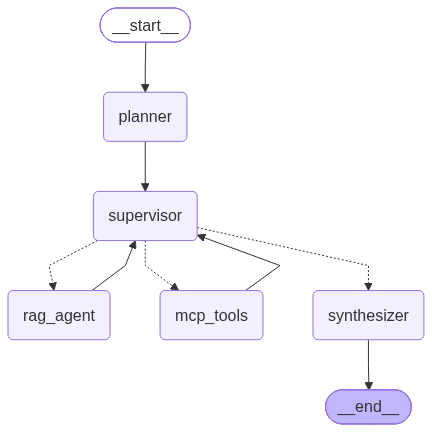

In [27]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Test the graph


In [28]:
retrieval_query = "What was the net income in 2023?"
retrieval_result = graph.invoke({"messages": [{"role": "user", "content": retrieval_query}]})
print(retrieval_result["messages"][-1].content)

[NOTICE] Using a Personal Authentication Token (PAT). Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2.0].


In [29]:
calculation_query = "What is 15% of 2.4 billion?"
calculation_result = graph.invoke({"messages": [{"role": "user", "content": calculation_query}]})
print(calculation_result["messages"][-1].content)

Processing request of type CallToolRequest
Processing request of type ListToolsRequest
Processing request of type CallToolRequest
Processing request of type ListToolsRequest


15% of 2.4 billion is 3.6e+08, or 360 million.


In [30]:
combined_query = "What was the revenue in 2023, and what would a 10% increase look like?"
for update in graph.stream(
    {"messages": [{"role": "user", "content": combined_query}]},
    stream_mode="updates",
):
    print(update)

{'planner': {'plan': ['Look up revenue in 2023', 'Calculate 10% of the revenue in 2023', 'Add the calculated 10% to the revenue in 2023'], 'current_step_index': 0, 'step_results': [], 'next_agent': '', 'final_answer': ''}}
{'supervisor': {'next_agent': 'rag_agent'}}
[NOTICE] Using a Personal Authentication Token (PAT). Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
{'rag_agent': {'step_results': ['¥16.91 trillion [source: annual_report.pdf, p.2.0]'], 'current_step_index': 1}}
{'supervisor': {'next_agent': 'mcp_tools'}}


Processing request of type CallToolRequest
Processing request of type ListToolsRequest


{'mcp_tools': {'step_results': ['¥16.91 trillion [source: annual_report.pdf, p.2.0]', '16.91 * 0.1 = 1.691'], 'current_step_index': 2}}
{'supervisor': {'next_agent': 'mcp_tools'}}


Processing request of type CallToolRequest
Processing request of type ListToolsRequest


{'mcp_tools': {'step_results': ['¥16.91 trillion [source: annual_report.pdf, p.2.0]', '16.91 * 0.1 = 1.691', '16.91 + 1.691 = 18.601'], 'current_step_index': 3}}
{'supervisor': {'next_agent': 'synthesizer'}}
{'synthesizer': {'final_answer': 'The revenue in 2023 was ¥16.91 trillion [source: annual_report.pdf, p.2.0]. A 10% increase would be ¥1.691 trillion, making the new revenue ¥18.601 trillion.', 'messages': [AIMessage(content='The revenue in 2023 was ¥16.91 trillion [source: annual_report.pdf, p.2.0]. A 10% increase would be ¥1.691 trillion, making the new revenue ¥18.601 trillion.', additional_kwargs={}, response_metadata={}, id='c2d4a6df-06a3-46dc-8c0e-3cb8e27e239b', tool_calls=[], invalid_tool_calls=[])]}}


### Required — offline smoke test
Runs the graph with a mocked LLM (no Databricks calls). Same test Bonus A automates.


In [31]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_smoke.py", "-q"],
    check=False,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
assert result.returncode == 0


.                                                                        [100%]



## Part 2 — Deployment
Package as an MLflow models-from-code model, register in Unity Catalog, create the serving endpoint (Tasks 2.1–2.4).
Reference: `databricks_deployment_v1/deployment.ipynb`.


In [32]:
# This rebuilds the production graph and validates every serving environment variable.
import importlib

import deployment.agent_model

importlib.reload(deployment.agent_model)
print("deployment.agent_model import OK")


deployment.agent_model import OK


Processing request of type ListToolsRequest


In [33]:
import os

from databricks.sdk import WorkspaceClient
from databricks.sdk.errors import NotFound

workspace = WorkspaceClient(host=settings["host"], token=settings["token"])
endpoint_name = os.environ["SERVING_ENDPOINT_NAME"]
endpoint_available = False
uc_model_name = "cs4603.student_27100077.document_analyst"
model_version = "8"
served_entity = {}
try:
    endpoint = workspace.serving_endpoints.get(endpoint_name).as_dict()
except NotFound:
    endpoint = None
else:
    endpoint_config = endpoint.get("config") or {}
    served_entities = endpoint_config.get("served_entities") or endpoint_config.get("served_models")
    if served_entities:
        endpoint_available = True
        served_entity = served_entities[0]
        uc_model_name = served_entity["entity_name"]
        model_version = served_entity["entity_version"]

if endpoint_available:
    print("active_model:", uc_model_name)
    print("active_version:", model_version)
    print("endpoint_state:", endpoint["state"])
else:
    print("endpoint_deleted_after_capture:", endpoint_name)
    print("captured_active_model:", uc_model_name)
    print("captured_active_version:", model_version)


active_model: cs4603.student_27100077.document_analyst
active_version: 9
endpoint_state: {'config_update': 'NOT_UPDATING', 'ready': 'READY'}


In [34]:
endpoint_url = f"{settings['host']}/serving-endpoints/{endpoint_name}/invocations"
environment_vars = served_entity.get("environment_vars", {})
print("endpoint_url:", endpoint_url)
if endpoint_available:
    print("served_entity:", served_entity["name"])
    print("workload_size:", served_entity.get("workload_size"))
    print("scale_to_zero_enabled:", served_entity.get("scale_to_zero_enabled"))
    print(
        "secret_refs:",
        {
            key: str(environment_vars.get(key, "")).startswith("{{secrets/")
            for key in ["DATABRICKS_HOST", "DATABRICKS_TOKEN", "DATABRICKS_MODEL"]
        },
    )
    print("non_bonus_mcp_stdio:", "MCP_SERVER_URL" not in environment_vars)
    assert endpoint["state"]["ready"] == "READY"
    assert endpoint["state"]["config_update"] == "NOT_UPDATING"
else:
    print("endpoint_available:", False)
    print("endpoint_status_check_skipped: endpoint was deleted after outputs were captured")


endpoint_url: https://dbc-93d5f280-aa05.cloud.databricks.com/serving-endpoints/27100077-document-analyst/invocations
served_entity: document-analyst-9
workload_size: Small
scale_to_zero_enabled: True
secret_refs: {'DATABRICKS_HOST': True, 'DATABRICKS_TOKEN': True, 'DATABRICKS_MODEL': True}
non_bonus_mcp_stdio: True


### Test the deployed endpoint (Task 2.4)


In [35]:
import json
import subprocess

from client.sdk import _extract_answer

if endpoint_available:
    payload = json.dumps({"messages": [{"role": "user", "content": retrieval_query}]})
    curl_result = subprocess.run(
        [
            "curl",
            "--silent",
            "--show-error",
            "--write-out",
            "\nHTTP_STATUS:%{http_code}\n",
            "-X",
            "POST",
            endpoint_url,
            "-H",
            f"Authorization: Bearer {settings['token']}",
            "-H",
            "Content-Type: application/json",
            "-d",
            payload,
        ],
        check=False,
        capture_output=True,
        text=True,
        timeout=240,
    )
    body = curl_result.stdout
    status = "unknown"
    if "\nHTTP_STATUS:" in body:
        body, status = body.rsplit("\nHTTP_STATUS:", 1)
        status = status.strip()
    print("curl_returncode:", curl_result.returncode)
    print("http_status:", status)
    print("response_bytes:", len(body.encode()))
    print("answer:", _extract_answer(json.loads(body)))
    assert curl_result.returncode == 0
    assert status == "200"
    assert body.strip()
else:
    print("curl_check_skipped: endpoint was deleted after submission outputs were captured")


curl_returncode: 0
http_status: 200
response_bytes: 754
answer: The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2.0].


In [36]:
import time

import requests

from client.sdk import _extract_answer

headers = {"Authorization": f"Bearer {settings['token']}"}
queries = [retrieval_query, calculation_query, combined_query]
deployed_answers = {}
if endpoint_available:
    for query in queries:
        started = time.perf_counter()
        response = requests.post(
            endpoint_url,
            headers=headers,
            json={"messages": [{"role": "user", "content": query}]},
            timeout=180,
        )
        response.raise_for_status()
        latency = time.perf_counter() - started
        answer = _extract_answer(response.json())
        deployed_answers[query] = answer
        print(f"{latency:.2f}s | {query}\n{answer}\n")
else:
    print("deployed_query_checks_skipped: endpoint was deleted after outputs were captured")

# Run this loop once after scale-to-zero (cold) and immediately again (warm), then
# compare these answers with the local outputs above. Differences can result from
# nondeterministic generation, model/config versions, and index refresh timing.


4.21s | What was the net income in 2023?
The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2.0].

6.58s | What is 15% of 2.4 billion?
15% of 2.4 billion is 3.6e+08, or 360 million.

8.10s | What was the revenue in 2023, and what would a 10% increase look like?
The revenue in 2023 was ¥16.91 trillion [source: annual_report.pdf, p.2.0]. A 10% increase would be ¥1.691 trillion, making the new revenue ¥18.601 trillion.



## Part 3 — Client SDK demo
Instantiate `DocumentAnalystClient`, health-check, ask, stream, and show timeout/retry handling (Task 3.2).


In [37]:
from client.sdk import DocumentAnalystClient

if endpoint_available:
    c = DocumentAnalystClient(os.environ["SERVING_ENDPOINT_NAME"])
    assert c.health_check() is True
    print("health:", c.health_check())
    print(c.ask(retrieval_query))
else:
    c = None
    print("health_check_skipped: endpoint was deleted after outputs were captured")


health: True
The net income in 2023 was ¥1,107 billion [source: annual_report.pdf, p.2.0].


In [38]:
if c is not None:
    for chunk in c.ask_streaming("Summarize FY2023 revenue."):
        print(chunk, end="", flush=True)
    print()
    c.close()
else:
    print("streaming_demo_skipped: endpoint was deleted after outputs were captured")


The FY2023 revenue is ¥16,910 billion, as stated in the annual report [source: annual_report.pdf, p.4.0].


In [39]:
from client.sdk import AnalystClientError

if endpoint_available:
    try:
        DocumentAnalystClient(os.environ["SERVING_ENDPOINT_NAME"], timeout=0.001).ask(
            retrieval_query
        )
    except TimeoutError as exc:
        print("Timeout handled:", exc)
else:
    print("timeout_demo_skipped: endpoint was deleted after outputs were captured")

try:
    DocumentAnalystClient("endpoint-that-does-not-exist", max_retries=2).ask(retrieval_query)
except AnalystClientError as exc:
    print("Unavailable endpoint handled:", exc)


Timeout handled: Document Analyst request timed out after 0.113 seconds
Unavailable endpoint handled: HTTP 404: The given endpoint does not exist, please retry after checking the specified model and version deployment exists. (request ID: 4949703d-f202-4ed8-9a5f-acea4fec4249)
